# Проект: вариант 2
## Задание 1. A/B–тестирование

In [37]:
# загрузка библиотек
import pandas as pd
import numpy as np
from scipy import stats
import scipy.stats as st
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
#from sklearn.preprocessing import OneHotEncoder as SklearnOneHotEncoder
#from statsmodels.regression.linear_model import OLS

### Загрузка, просмотр и обработка данных 

In [2]:
active_studs = pd.read_csv('Проект_2_active_studs.csv',sep=';')
active_studs.head(3)

,student_id
0,581585
1,5723133
2,3276743


In [3]:
active_studs.shape

(8341, 1)

In [4]:
checks = pd.read_csv('Проект_2_checks.csv',sep=';')
checks.head(3)

,student_id,rev
0,1627,990.0
1,3185,690.0
2,25973,690.0


In [21]:
checks.shape

(541, 2)

In [6]:
checks.rev.nunique()

39

In [7]:
groups = pd.read_csv('Проект_2_groups.csv', sep=';')
groups.head(3)

,id,grp
0,1489,B
1,1627,A
2,1768,B


In [8]:
groups.shape

(74484, 2)

In [9]:
groups.grp.value_counts()

B    59813
A    14671
Name: grp, dtype: int64

In [10]:
group_ad = pd.read_csv('Проект_2_group_add.csv')
group_ad.head(3)

,id,grp
0,5694584,B
1,5694830,B
2,5695057,B


In [11]:
group_ad.shape

(92, 2)

In [12]:
group_ad.grp.value_counts()

B    70
A    22
Name: grp, dtype: int64

### Предварительный анализ данных показал, что количество пользователей практически на порядок больше количества  активных пользователей и на два порядка больше количества пользователей, совершивших покупки. 

### Количество пользователей в целевой группе (В) в несколько раз больше количества пользователей в контрольной группе (А).

#### Объединим в датафрейме groups_new всю информацию о пользователях (student_id), включая  наличие операций в период теста (active), платежи в период теста (rev) и принадлежность к контрольной (А) и тестовой (В) группе


In [13]:
# Объединим данные о группах. Структура датафреймов одинакова, поэтому используем функцию concat для добавления новых данных.
groups_new = pd.concat([groups, group_ad])
# Переименуем название столбца id в student_id для удобства объединения по этому полю
groups_new = groups_new.rename(columns={'id':'student_id'}).reset_index(drop=True)
# К датафрейму groups_new добавим столбец active с признаком активности клиентов
groups_new['active'] = np.where(groups_new['student_id'].isin(active_studs['student_id']), 1, 0)
# К датафрейму groups_new добавим столбец rev с информацией о платежах клиентов
groups_new = groups_new.merge(checks, how='left', on='student_id')
groups_new.head()

,student_id,grp,active,rev
0,1489,B,0,NaN
1,1627,A,1,990.0
2,1768,B,0,NaN
3,1783,B,0,NaN
4,1794,A,0,NaN



#### Проверим наличие багов - наличие платежей при неактивном статусе 

In [14]:
groups_new.query('rev.notna() & active==0')

,student_id,grp,active,rev
39,3185,B,0,690.0
121,25973,B,0,690.0
125,26280,B,0,690.0
223,100645,B,0,630.0
254,102534,B,0,580.0
...,...,...,...,...
72452,5291900,B,0,199.0
72753,5331842,B,0,290.0
73632,5486319,B,0,199.0
74049,5562806,B,0,398.0


#### Исправим баги

In [16]:
groups_new = groups_new.query('not (rev.notna() & active==0)')
# проверим отсутствие багов 
groups_new.query('rev.notna() & active==0').agg({'student_id':'count'})

student_id    0
dtype: int64

#### Сформируем датафрейм платящих клиентов  со всей доступной информацией о них и проведем предварительный анализ выручки в контрольной и тестовой группах

In [17]:
checks_new = groups_new.query('rev.notna()').reset_index(drop=True)
checks_new.shape
#checks_new.head()

(392, 4)

In [18]:
#  Рассмотрим статистику выручки для группы А
checks_new.query('grp=="A"').rev.describe()

count      78.000000
mean      933.589744
std       919.932711
min       199.000000
25%       290.000000
50%       585.000000
75%      1114.750000
max      3660.000000
Name: rev, dtype: float64

In [19]:
# Рассмотрим статистику сумм выручки для группы В
checks_new.query('grp=="B"').rev.describe()

count     314.000000
mean     1257.878992
std       790.864254
min       199.000000
25%       511.750000
50%      1140.000000
75%      1900.000000
max      4650.000000
Name: rev, dtype: float64

#### Из приведенных статистических данных для распределений сумм выручки в группах отметим
- #### средняя величина (ARPPU) в тестовой группе больше, чем в контрольной - 1258 и 934 соответственно,
- #### медиана в тестовой группе больше, чем в котрольной - 1140 и 585 соответственно,
- #### максимальное значение в тестовой группе также больше, чем в контрольной - 4650 и 3660 соответственно.

#### Рассмотрим форму распределений выручки  для групп А и В

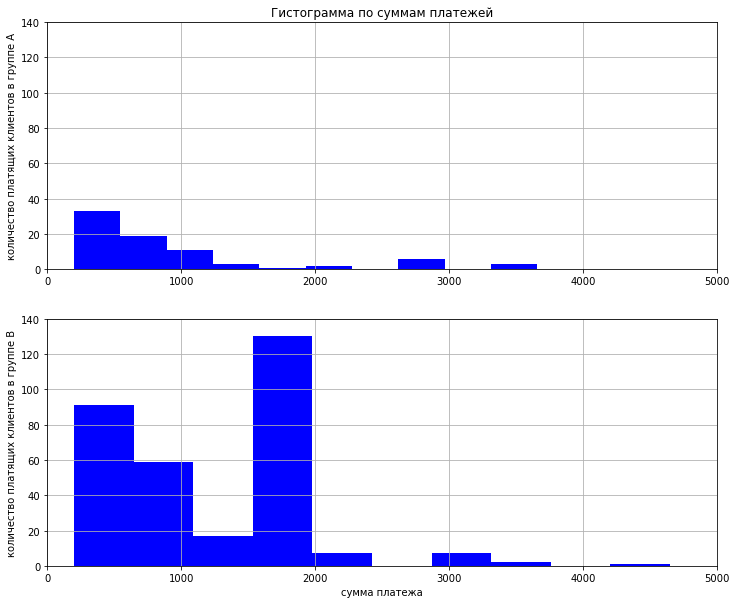

In [20]:
plt.figure(figsize=(12,10))
checks_A = checks_new.query('grp=="A"').rev
plt.subplot(2,1,1) 
plt.hist(checks_A.values, color='blue')
plt.title('Гистограмма по суммам платежей')
plt.ylabel('количество платящих клиентов в группе А')
plt.axis([0,5000,0,140])
plt.grid(True)
plt.subplot(2,1,2) 
checks_B = checks_new.query('grp=="B"').rev
plt.hist(checks_B.values, color='blue')
plt.ylabel('количество платящих клиентов в группе В')
plt.xlabel('сумма платежа')
plt.axis([0,5000,0,140])
plt.grid(True)

#### Из приведенных гистограмм видно, что
- #### в целевой группе (В) больше доля клиентов, cовершивших покупки на большую сумму,
- #### появилась вторая мода на относительно высоком уровне 1800-2000.

### Вывод по предварительному анализу распределения выручки в контрольной и тестовой группах

- ### Сравнение статистических данных показало значительный прирост средней выручки на одного платящего клиента   (ARPPU) в целевой  группе (В) по сравнению с контрольной (А), соответственно с 934 до 1257

- ### Анализ гистограмм распределения выручки показал, что отмеченный прирост ARPPU обусловлен большей долей клиентов, cовершивших покупки на большую сумму, а также появлением второй моды на относительно высоком уровне 1800-2000
. 





#### Далее проведем анализ и сравнение метрик эффективности при проведении А/В тестирования

###  В качестве основной метрики эффективности, напрямую связанной с экономической эффективностью и доходом предлагается 
- ### ARPU - средняя сумма выручки на одного клиента 

В свою очередь 
###       ARPU = CTP * ARPPU 

### Таким образом в качестве метрик сравнения в А/В тесте рассмотрим
- ### ARPU   - средняя сумма выручки на одного клиента,
- ### CTP      - конверсия в платящего клиента,
- ### ARPPU - средняя сумму выручки на одного платящего клиента

#### Вначале рассмотрим метрику конверсии CTP
При расчете метрики конверсии используются номинативная переменная, характеризующая факт совершения покупки - да или нет.  
В этом случае для проверки статистической значимости различий между контрольной и целевой группой можно использовать критерий
Пирсона (хи-квадрат).

В качестве гипотезы H0 примем гипотезу, что статистически значимых различий в коэффициенте конверсии в платящих клиентов для  групп А(контрольная) и В(целевая) нет. 

Уровень значимости примем равным  0.05 

In [33]:
# Построим матрицу сегментации клиентов по группам (segment matrix) для столбцов:
#                                              number (общее количество клиентов в тесте А+В), 
#                                              active (количество активных клиентов),
#                                              paying (количество платящих клиентов)
                                            
segment_matrix = groups_new.groupby('grp',as_index=False)\
                  .agg({'student_id':'count',
                        'active'    :'sum',
                        'rev'       :'count' })\
                   .rename(columns={
                         'student_id':'number',
                          'rev'      :'paying'})\
                    .set_index('grp')
segment_matrix

,number,active,paying
grp,,,
A,14664,1538,78
B,59763,6803,314


In [34]:
# Оценим коэффициенты конверсии в платящих клиентов для групп A и В
CTP_A = segment_matrix.iloc[0,2]/segment_matrix.iloc[0,0]
CTP_B = segment_matrix.iloc[1,2]/segment_matrix.iloc[1,0]
print(f'конверсия в платящих клиентов CTP для группы A - {CTP_A:.4f}')
print(f'                                             B - {CTP_B:.4f}')

конверсия в платящих клиентов CTP для группы A - 0.0053
                                             B - 0.0053


In [35]:
# Оценим статистическую значимость сохранения или отклонения нулевой гипотезы
# Для дальнейших расчетов пропорционально увеличим столцы active и paying, чтобы обеспечить равенство сумм по столбцам 
conjugacy_matrix = segment_matrix
conjugacy_matrix['active'] = (segment_matrix['active'] * segment_matrix['number'].sum()\
                                                            / segment_matrix['active'].sum())\
                                                            .round(0).astype('int')

conjugacy_matrix['paying'] = (segment_matrix['paying'] * segment_matrix['number'].sum()\
                                                            / segment_matrix['paying'].sum())\
                                                             .round(0).astype('int')
conjugacy_matrix

,number,active,paying
grp,,,
A,14664,13724,14809
B,59763,60703,59618


In [38]:
# В качестве столбца наблюдений  используем paying, а столбца ожиданий number 
observed = conjugacy_matrix['paying']
expected = conjugacy_matrix['number']
# Применем программу chisquare из библиотеки stats для получения величины статистики и p-value
stats.chisquare(f_obs=observed, f_exp=expected)

Power_divergenceResult(statistic=1.785589716724214, pvalue=0.18146443674964646)

#### pvalue=0.18, что значительно больше уровня значимости 0.05
### Вывод
- ### Таким образом сохраняется нулевая гипотеза Н0 и изменение коэффициента конверсии не является статистически значимым.

- ### Ключевой метрикой для анализа эффективности предложенных изменений является ARPPU, которая показала значительный прирост в целевой группе по сравнению с контрольной.

#### Далее проведем исследование метрики ARPPU для контрольной (А) и тестовой (В) группы и проверим статистическую значимость ее прироста в тестовой группе.


#### Построим графики boxplot для групп А и В

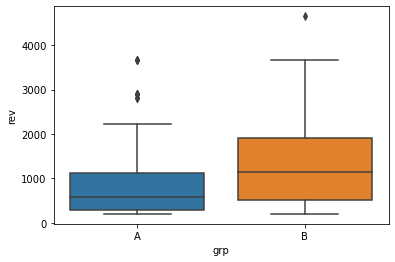

In [24]:
sns.boxplot(x='grp', y='rev', data=checks_new)

#### Анализ графиков показывает, что 
- #### функции распределения несимметричны и имеют выбросы, что свидетельствует о нарушении 'нормальности' распределений,
- #### Выбросы не являются чрезмерно большими, и по величине и по количеству (на два порядка меньше общего количества наблюдений). 

#### Построим гистограммы распределений выручки для групп А и В

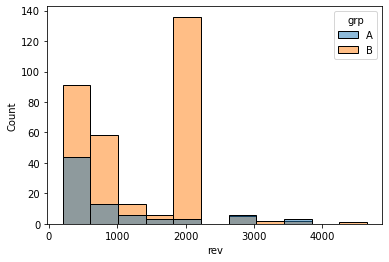

In [25]:
sns.histplot(x='rev', hue='grp', data=checks_new)

#### Анализ графиков показал, что функция распределения выручки 
- #### не симметрична, 
- #### смещена вправо,
- #### для группы В не унимодальна - появилась 2-ая мода на относительно высоком уровне 2000 

#### Таким образом анализ графиков показал, что распределения не являются нормальными.

#### Проверим нормальность распределений статистическим тестом Шапиро_Уилка (подходит для количества измерений <5000)

In [28]:
control = checks_new.query("grp == 'A'").rev
test = checks_new.query("grp == 'B'").rev
print(st.shapiro(control))
print(st.shapiro(test))

ShapiroResult(statistic=0.7353236442181668, pvalue=1.49869203824321e-10)
ShapiroResult(statistic=0.8547218120137667, pvalue=1.5433362141142128e-16)


#### Как видно из результатов тестов p-value гораздо меньше 0.05 и нулевая гипотеза о нормальности распределений отвергается.

#### Проверим распределения на равенство дисперсий, используя тест Левена

In [31]:
st.levene(control, test)

LeveneResult(statistic=3.075681699981606, pvalue=0.08025675761347022)

#### Как видно из результатов теста  pvalue=0.08 и нулевая гипотеза о равенстве дисперсий не отвергается. 

##### Далее рассмотрим выбор стат теста для подтверждения прироста ARPPU в тестовой группе

#### Анализируемая метрика ARPPU - количественная и является средним значением. Для анализа статстической значимости различия средних значений  часто используется t-test.
#### Рассмотрим допущения применимости t-testа в порядке убывания их значимости
1. #### Независимость наблюдений. Значения платежей клиентов в контрольной и тестовой группах не связаны и это допущение выполняется,
2. #### Отсутствие аномальных наблюдений. Выбросы присутствуют, но их влияние незначительно. Допущение выполняется,
3. #### Равенство дисперсий не отвергается стат тестом. Допущение выполняется,
4. #### Нормальность распределения. Не выполняется, но практически не влияет на ограничение применимости рассматриваемого теста, так как количество наблюдений достаточно велико (гораздо больше 30).

#### Таким образом отмеченные выше допущения выполняются и в качестве  статистического теста применим  t-test.

#### В качестве нулевой гипотезы H0 примем гипотезу, о равенстве средних значений выручки платящих клиентов ARPPU в контрольной (А) и тестовой (В) группах.

#### Уровень значимости примем равным 0.05

In [32]:
# Применим t-test
st.ttest_ind(control, test)

TtestResult(statistic=-3.1337795050930985, pvalue=0.001856202526576587, df=390.0)

### Вывод
### Применение t-testa показало, что в А/В эксперименте прирост средней выручки на одного платящего клиента ARPPU в  целевой группе по сравнению с контрольной статистически значим (p value = 0.0018 < 0.05)
### Величина этого прироста в проведенном  А/В тесте составила 34%, с 934 до 1258 соответственно.

### Таким образом А/В эксперимент показал эффективность новой механики расчетов и ее можно применять для всех пользователей.


## Задание 2. SQL
### Сегментация клиентов для персонализированного маркетинга

In [ ]:
#для корректного просмотра необходимо нажать ENTER на следующей маркдаун ячейке

WITH orders_count AS (
    SELECT 
       customer_id,
       SUM(CASE WHEN order_status = 'Delivered' THEN 1 ELSE 0 END) AS orders_count
    FROM orders
    GROUP BY 1
),
 purchase_events_count AS (
    SELECT
       customer_id,
       SUM(CASE WHEN event_type = 'Purchase' THEN 1 ELSE 0 END) AS purchase_events_count
    FROM customer_actions 
    GROUP BY 1 
),
  avg_delivery_days AS (
    SELECT
        customer_id,
        AVG(CASE WHEN order_delivered_customer_time IS NOT NULL 
                 THEN EXTRACT(EPOCH FROM(order_delivered_customer_time - order_created_time))/86400.0
                 ELSE NULL END
            ) AS avg_delivery_days
    FROM orders 
    GROUP BY 1
)

SELECT 
    c.customer_id,
    c.customer_city,
    c.created_at AS registration_date, 
    '2024-03-31'- c.created_at AS days_since_registration, 
    oc.orders_count,
    pe.purchase_events_count,
    ad.avg_delivery_days,
    CASE
        WHEN oc.orders_count >= 3 THEN 'Постоянный'
        WHEN oc.orders_count >= 1 THEN 'Разовый'
        WHEN oc.orders_count = 0 AND ('2024-03-31'- c.created_at) > 30 THEN 'Неактивный'
        WHEN oc.orders_count = 0 AND ('2024-03-31'- c.created_at) <= 30 THEN 'Новый'
        END AS segment
FROM customers c 
JOIN orders_count oc ON c.customer_id=oc.customer_id
JOIN purchase_events_count pe ON c.customer_id=pe.customer_id
JOIN avg_delivery_days ad ON c.customer_id=ad.customer_id


## Задание 3. Python

### Реализуйте функцию, которая будет автоматически подгружать информацию из дополнительного файла groups_add.csv (заголовки могут отличаться) и на основании дополнительных параметров пересчитывать метрики.



#### Для реализации функции неoбходимо создать файл crontab и ввести в него следующую инструкцию
####     00 10 * * * project_2_3_1.py

#### в соответствии с этой инструкцией cron каждый день в 10.00 будет исполнять файл project_2_3_1, обновляя информацию  из файлов  входных данных и выводя на печать метрики CTP, ARPPU и ARPU для контрольной (А) и тестовой (B) группы.
#### Кроме этого в текущую директорию записываеся файл metrix.csv c указанными метриками для построения их графиков с помощью файла project_2_3_2.py. 
#### Файлы project_2_3_1.py и project_2_3_2.py представлены ниже.

In [ ]:
# Файл project_2_3_1.py - подгружает информацию и пересчитывает метрики

# загрузка библиотек
import pandas as pd
import numpy as np
from scipy import stats
#import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

#Загрузка и обработка данных
active_studs = pd.read_csv('Проект_2_active_studs.csv',sep=';')
checks = pd.read_csv('Проект_2_checks.csv',sep=';')
groups = pd.read_csv('Проект_2_groups.csv', sep=';')
group_ad = pd.read_csv('Проект_2_group_add.csv')
# Объединим группы groups и group_ad. Структура датафреймов одинакова, поэтому используем функцию concat для добавления
#новых данных.
groups_new = pd.concat([groups, group_ad])



# Переименуем название столбца id в student_id для удобства объединения по этому полю
groups_new = groups_new.rename(columns={'id':'student_id'}).reset_index(drop=True)
# Добавим к датафрейму checks информацию о группах используя метод .merge
checks_new = checks.merge(groups_new, how='left', on='student_id')

ARPPU_A = checks_new.query('grp=="A"').rev.mean().round(0)
ARPPU_B = checks_new.query('grp=="B"').rev.mean().round(0)

# Преобразуем датафрейм groups_new для анализа указанных метрик
groups_new = groups_new.merge(checks, how='left', on='student_id')
# к анализируемому датафрейму groups_new добавим столбец active с признаком активности клиентов
groups_new['active'] = np.where(groups_new['student_id'].isin(active_studs['student_id']), 1, 0)

# Построим матрицу сегментации клиентов по группам  (segment matrix) для столбцов:
#                                              number (общее количество клиентов в тесте А+В), 
#                                              active (количество активных клиентов),
#                                              paying (количество платящих клиентов)

segment_matrix = groups_new.groupby('grp',as_index=False)\
                  .agg({'student_id':'count',
                        'active'    :'sum',
                        'rev'       :'count' })\
                   .rename(columns={
                         'student_id':'number',
                          'rev'      :'paying'})\
                   .set_index('grp')

# Оценим коэффициенты конверсии в платящих клиентов для групп A и В
CTP_A = round(segment_matrix.iloc[0,2]/segment_matrix.iloc[0,0], 4)
CTP_B = round(segment_matrix.iloc[1,2]/segment_matrix.iloc[1,0], 4)
# Сформируем матрицу метрик
metrix = pd.DataFrame({'group' : ['A','B'],
                      'CTP'   : [CTP_A, CTP_B],
                      'ARPPU' : [ARPPU_A, ARPPU_B],
                      'ARPU'  : [round(ARPPU_A*CTP_A, 1), round(ARPPU_B*CTP_B, 1)]})

metrix.to_csv('metrix.csv', index=False, sep=';', encoding='utf-8')
print(f'конверсия в платящих клиентов CTP          для группы A - {CTP_A:.4f}')
print(f'                                                      B - {CTP_B:.4f}')
print(' ')
print(f'средняя выручка на платящего клиента ARPPU для группы А - {ARPPU_A:.0f}')
print(f'                                                      B - {ARPPU_B:.0f}')
print(' ')
print(f'средняя выручка на клиента ARPU            для группы А - {ARPPU_A*CTP_A:.1f}')
print(f'                                                      B - {ARPPU_B*CTP_B:.1f}')



In [ ]:
# Файлы project_2_3_2.py  - строит графики по получаемым метрикам.

# загрузка библиотек
import pandas as pd
import numpy as np
from scipy import stats
#import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

metrix = pd.read_csv('metrix.csv', sep=';')

plt.figure(figsize=(12,18))
plt.subplot(3,1,1) 
sns.barplot(data=metrix, x='group', y='CTP', color='blue') 
plt.title('Конверсия в платящих клиентов CTP в контрольной (А) и тестовой (В) группах')
plt.ylabel('CTP')
# Получение позиций меток по оси X
xticks = plt.gca().get_xticks()
plt.axis([-1,2,0,0.009])
# Добавление значений на график
for index, row in metrix.iterrows():
    plt.text(xticks[index], row['CTP'], f"{row['CTP']:.4f}", ha='center', va='bottom')
plt.xlabel(' ')
#plt.grid(True)
plt.subplot(3,1,2) 
sns.barplot(data=metrix, x='group', y='ARPPU', color='blue')  
plt.title('Средняя выручка на платящего клиента ARPPU в контрольной (А) и тестовой (В) группах')
plt.ylabel('ARPPU')
plt.xlabel(' ')
xticks = plt.gca().get_xticks()
# Добавление значений на график
for index, row in metrix.iterrows():
    plt.text(xticks[index], row['ARPPU'], f"{row['ARPPU']:.0f}", ha='center', va='bottom')
plt.axis([-1,2,0,1200])
#plt.grid()
sns.despine()
plt.subplot(3,1,3) 
sns.barplot(data=metrix, x='group', y='ARPU', color='blue')  
plt.title('Средняя выручка на клиента ARPU в контрольной (А) и тестовой (В) группах')
plt.ylabel('ARPU')
xticks = plt.gca().get_xticks()
# Добавление значений на график
for index, row in metrix.iterrows():
    plt.text(xticks[index], row['ARPU'], f"{row['ARPU']:.1f}", ha='center', va='bottom')
plt.axis([-1,2,0,10])
plt.xlabel('контрольная (A) и тестовая (В) группы')
#plt.grid()
sns.despine()
# Увеличиваем расстояние между подграфиками
plt.subplots_adjust(hspace=0.3)  # hspace - расстояние между строками
plt.show()


### Файл DAG (project_2_dag.py) для загрузки в AIRFLOW

In [ ]:
# загрузка библиотек
import requests
import pandas as pd
import numpy as np
from scipy import stats
from datetime import timedelta
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from airflow import DAG
from airflow.operators.python import PythonOperator

def download_link(google_drive_link):
    # Извлечь идентификатор файла из ссылки  
    file_id = google_drive_link.split("/")[-2]  
    # Сгенерировать ссылку для скачивания  
    download_link = f"https://drive.google.com/uc?id={file_id}" 
    return download_link

# Публичная ссылка на CSV-файл в Google Drive    
active_google_link    = "https://drive.google.com/file/d/1OdymlYeTKl_3flDbl0cBOocErjzGZ40H/view?usp=sharing"
checks_google_link    = "https://drive.google.com/file/d/1eDLgU_tuL9kmeFKMSaVaPQlZyU9cg-jQ/view?usp=sharing"
groups_google_link    = "https://drive.google.com/file/d/19XOPoC1rtwipdbCf3YZXqf52EKHdWsXX/view?usp=sharing"
group_add_google_link = "https://drive.google.com/file/d/1Ux9WFxAAqyadv55F2qTfJLSgCYF56f1c/view?usp=sharing"

# Загрузка и обработка данных
def get_data():
    # Читать CSV-файл с помощью pandas  
    active    = pd.read_csv(download_link(active_google_link))
    checks    = pd.read_csv(download_link(checks_google_link),sep=';')
    groups    = pd.read_csv(download_link(groups_google_link), sep=';')
    group_add = pd.read_csv(download_link(group_add_google_link))
    # Объединим группы groups и group_ad. Структура датафреймов одинакова, поэтому используем функцию concat для добавления
    #новых данных.  
    groups_new = pd.concat([groups, group_add])
    # Переименуем название столбца id в student_id для удобства объединения по этому полю
    groups_new = groups_new.rename(columns={'id':'student_id'}).reset_index(drop=True)
    # Добавим к датафрейму checks информацию о группах используя метод .merge
    checks_new = checks.merge(groups_new, how='left', on='student_id')
    # Преобразуем датафрейм groups_new для анализа указанных метрик
    groups_new = groups_new.merge(checks, how='left', on='student_id')
    # к анализируемому датафрейму groups_new добавим столбец active с признаком активности клиентов
    groups_new['active'] = np.where(groups_new['student_id'].isin(active['student_id']), 1, 0)
    return checks_new, groups_new


# расчет  метрик
def get_metrics():  
    checks_new, groups_new = get_data()
    ARPPU_A = checks_new.query('grp=="A"').rev.mean().round(0)
    ARPPU_B = checks_new.query('grp=="B"').rev.mean().round(0)
    # Построим матрицу сегментации клиентов по группам  (segment matrix) для столбцов:
    #                                              number (общее количество клиентов в тесте А+В), 
    #                                              active (количество активных клиентов),
    #                                              paying (количество платящих клиентов)

    segment_matrix = groups_new.groupby('grp',as_index=False)\
                      .agg({'student_id':'count',
                            'active'    :'sum',
                            'rev'       :'count' })\
                       .rename(columns={
                             'student_id':'number',
                              'rev'      :'paying'})\
                       .set_index('grp')

    # Оценим коэффициенты конверсии в платящих клиентов для групп A и В
    CTP_A = round(segment_matrix.iloc[0,2]/segment_matrix.iloc[0,0], 4)
    CTP_B = round(segment_matrix.iloc[1,2]/segment_matrix.iloc[1,0], 4)
    # Сформируем матрицу метрик
    metrics = pd.DataFrame({'group' : ['A','B'],
                          'CTP'   : [CTP_A, CTP_B],
                          'ARPPU' : [ARPPU_A, ARPPU_B],
                          'ARPU'  : [round(ARPPU_A*CTP_A, 1), round(ARPPU_B*CTP_B, 1)]})

    #metrix.to_csv('metrix.csv', index=False, sep=';', encoding='utf-8')
    return metrics
    
# Печать метрик
def print_metrics()
    metrics = get_metrics()
    print(f'конверсия в платящих клиентов CTP          для группы A - {metrics.iloc[0,1]:.4f}')
    print(f'                                                      B - {metrics.iloc[1,1]:.4f}')
    print(' ')
    print(f'средняя выручка на платящего клиента ARPPU для группы А - {metrics.iloc[0,2]:.0f}')
    print(f'                                                      B - {metrics.iloc[1,2]:.0f}')
    print(' ')
    print(f'средняя выручка на клиента ARPU            для группы А - {metrics.iloc[0,1]*metrics.iloc[0,2]:.1f}')
    print(f'                                                      B - {metrics.iloc[1,1]*metrics.iloc[1,2]:.1f}')
    return 

# Построение графиков метрик
def chart_metrics()
    metrics = get_metrics()
    plt.figure(figsize=(12,18))
    plt.subplot(3,1,1) 
    sns.barplot(data=metrics, x='group', y='CTP', color='blue') 
    plt.title('Конверсия в платящих клиентов CTP в контрольной (А) и тестовой (В) группах')
    plt.ylabel('CTP')
    # Получение позиций меток по оси X
    xticks = plt.gca().get_xticks()
    # Добавление значений на график
    for index, row in metrics.iterrows():
        plt.text(xticks[index], row['CTP'], f"{row['CTP']:.4f}", ha='center', va='bottom')
    plt.xlabel(' ')
    #plt.grid(True)
    plt.subplot(3,1,2) 
    sns.barplot(data=metrics, x='group', y='ARPPU', color='blue')  
    plt.title('Средняя выручка на платящего клиента ARPPU в контрольной (А) и тестовой (В) группах')
    plt.ylabel('ARPPU')
    plt.xlabel(' ')
    xticks = plt.gca().get_xticks()
    # Добавление значений на график
    for index, row in metrics.iterrows():
        plt.text(xticks[index], row['ARPPU'], f"{row['ARPPU']:.0f}", ha='center', va='bottom')
    #plt.grid()
    sns.despine()
    plt.subplot(3,1,3) 
    sns.barplot(data=metrics, x='group', y='ARPU', color='blue')  
    plt.title('Средняя выручка на клиента ARPU в контрольной (А) и тестовой (В) группах')
    plt.ylabel('ARPU')
    xticks = plt.gca().get_xticks()
    # Добавление значений на график
    for index, row in metrics.iterrows():
        plt.text(xticks[index], row['ARPU'], f"{row['ARPU']:.1f}", ha='center', va='bottom')
    plt.xlabel('контрольная (A) и тестовая (В) группы')
    #plt.grid()
    sns.despine()
    plt.subplots_adjust(hspace=0.4)
    plt.show()
    return


default_args = {
    'owner': 'avladimirov007',
    'depends_on_past': False,
    'retries': 2,
    'retry_delay': timedelta(minutes=5),
    'start_date': datetime(2026, 3, 19),
}
schedule_interval = '00 10 * * *'

dag = DAG('DAG_metrics', default_args=default_args, schedule_interval=schedule_interval)

t1 = PythonOperator(task_id='get_data',
                    python_callable=get_data,
                    dag=dag)

t2 = PythonOperator(task_id='get_metrics',
                    python_callable=get_metrics,
                    dag=dag)

t3_com = PythonOperator(task_id='print_metrics',
                        python_callable=print_metrics,
                        dag=dag)

t4 = PythonOperator(task_id='chart_metrics',
                    python_callable=chart_metrics,
                    dag=dag)

t1 >> t2 >> t3 >> t4

#t1.set_downstream(t2)

#t2.set_downstream(t3)
#t3.set_downstream(t4)